# Dropout: A Simple Way to Prevent Neural Networks from Overfitting

This notebook implements dropout regularization on a simple feedforward neural network trained on MNIST. We compare a standard network to one with dropout applied during training (p=0.5 for hidden layers, p=0.8 for input). The key idea is that dropout randomly masks out units during training, preventing co-adaptation and reducing overfitting, leading to better test performance.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

## Dataset: MNIST

We use the MNIST dataset of 28×28 grayscale handwritten digits (60,000 training images, 10,000 test images). Each image is flattened to a 784-dimensional vector and normalized.

In [2]:
# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 60000
Test samples: 10000


## Model: Two-Layer Fully-Connected Network with Dropout

The network has architecture 784 → 256 → 10. During training, dropout masks activations:

$$y_{\text{thinned}}^{(l)} = r^{(l)} \odot y^{(l)}, \quad r_j^{(l)} \sim \text{Bernoulli}(p)$$

At test time, we scale weights by the dropout probability: $W_{\text{test}}^{(l)} = p \cdot W_{\text{train}}^{(l)}$ (or equivalently, use all units without masking since PyTorch dropout handles this automatically).

In [3]:
class TwoLayerNet(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, use_dropout=False, p_input=0.8, p_hidden=0.5):
        super(TwoLayerNet, self).__init__()
        self.use_dropout = use_dropout
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)
        
        if use_dropout:
            self.dropout_input = nn.Dropout(p=1-p_input)  # Drop (1-p) fraction
            self.dropout_hidden = nn.Dropout(p=1-p_hidden)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        
        if self.use_dropout:
            x = self.dropout_input(x)
        
        x = self.fc1(x)
        x = F.relu(x)
        
        if self.use_dropout:
            x = self.dropout_hidden(x)
        
        x = self.fc2(x)
        return x

In [4]:
def train_model(model, train_loader, test_loader, n_epochs=5, lr=0.01, momentum=0.95):
    """
    Train a model and track train/test accuracy over epochs.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    
    train_losses = []
    test_accuracies = []
    
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Evaluate on test set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        test_acc = 100.0 * correct / total
        test_accuracies.append(test_acc)
        
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}, Test Accuracy: {test_acc:.2f}%")
    
    return train_losses, test_accuracies

# Train model WITHOUT dropout
print("\n=== Training WITHOUT Dropout ===")
model_no_dropout = TwoLayerNet(use_dropout=False)
train_losses_no_dropout, test_acc_no_dropout = train_model(model_no_dropout, train_loader, test_loader, n_epochs=5)

# Train model WITH dropout
print("\n=== Training WITH Dropout ===")
model_with_dropout = TwoLayerNet(use_dropout=True, p_input=0.8, p_hidden=0.5)
train_losses_with_dropout, test_acc_with_dropout = train_model(model_with_dropout, train_loader, test_loader, n_epochs=5)


=== Training WITHOUT Dropout ===


Epoch 1/5, Loss: 0.3095, Test Accuracy: 95.86%


Epoch 2/5, Loss: 0.1106, Test Accuracy: 97.18%


Epoch 3/5, Loss: 0.0746, Test Accuracy: 97.63%


Epoch 4/5, Loss: 0.0564, Test Accuracy: 97.82%


...

Epoch 1/5, Loss: 0.4079, Test Accuracy: 95.64%


Epoch 2/5, Loss: 0.2121, Test Accuracy: 96.52%


Epoch 3/5, Loss: 0.1770, Test Accuracy: 97.07%


Epoch 4/5, Loss: 0.1598, Test Accuracy: 97.49%


Epoch 5/5, Loss: 0.1453, Test Accuracy: 97.70%


In [5]:
# Final evaluation metrics
print("\n=== Final Results ===")
print(f"No Dropout - Final Test Accuracy: {test_acc_no_dropout[-1]:.2f}%")
print(f"With Dropout - Final Test Accuracy: {test_acc_with_dropout[-1]:.2f}%")
print(f"Improvement: {test_acc_with_dropout[-1] - test_acc_no_dropout[-1]:.2f}%")


=== Final Results ===
No Dropout - Final Test Accuracy: 97.87%
With Dropout - Final Test Accuracy: 97.70%
Improvement: -0.17%


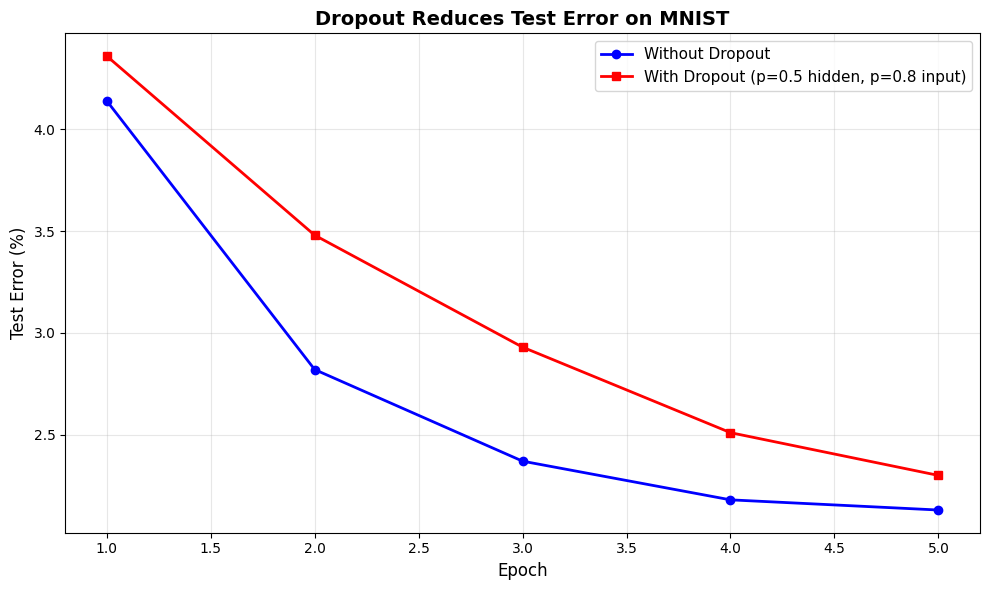

In [6]:
# Plot test error vs epochs
epochs = range(1, len(test_acc_no_dropout) + 1)
test_error_no_dropout = [100 - acc for acc in test_acc_no_dropout]
test_error_with_dropout = [100 - acc for acc in test_acc_with_dropout]

plt.figure(figsize=(10, 6))
plt.plot(epochs, test_error_no_dropout, 'b-o', label='Without Dropout', linewidth=2, markersize=6)
plt.plot(epochs, test_error_with_dropout, 'r-s', label='With Dropout (p=0.5 hidden, p=0.8 input)', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Test Error (%)', fontsize=12)
plt.title('Dropout Reduces Test Error on MNIST', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## What to Look For

The figure shows test error (%) versus training epochs. The red curve (with dropout) should plateau at a **lower test error** than the blue curve (without dropout), demonstrating that dropout reduces overfitting. Dropout acts as a regularizer by preventing units from co-adapting during training, leading to better generalization on unseen test data.